# LSD, Psilocybin and Ketamine in the Long COVID / ME-CFS Community

**A within-patient analysis of self-reported treatment outcomes.**

Source: `data/full_corpus_2026-07-31/` — 69,161 patient records extracted from 15
long-COVID / ME-CFS subreddits, 204,417 `treatment_outcome` triples.

This notebook is statistics only. Methods, Results, Conclusion. Narrative prose is
deliberately left out.

---

### The question, and why the obvious analysis is wrong

The community treats these three substances as one family. A naive read of this corpus
says psilocybin is reported as helping 81% of the time against a 67% corpus-wide
average — but the people who write about psychedelics are not the corpus average. They
are sicker, they have far heavier mood and cognitive symptom loads, and they name a
median of 7 treatments each. The comparison measures *who reports*, not *what the drug did*.

So the comparator here is **the patient themselves**: every psychedelic outcome is
compared against the same patient's outcomes for their own other treatments, with patient
fixed effects. The two documented biases in this dataset — an extractor that over-calls
positive, and stacked treatments inheriting a collective outcome — apply to both arms
inside the same record and largely cancel.

---
# 1. Methods

## 1.1 Data source and unit of analysis

Input is `records_covidlonghaulers_v2.json`, the run's authoritative dataset, rather than the
`records.csv` convenience table, which is documented as lossy.

One record is one **patient**, not one post — every post and comment by an author across
the whole corpus was concatenated and extracted in a single LLM call (deepseek-v4-flash,
temperature 0). Authors with fewer than 3 text segments were dropped.

The analysis unit below is one **outcome triple**: `drug : outcome : symptom`, e.g.
`"psilocybin: helped: brain fog"`. Outcome is a closed 5-value vocabulary.

In [1]:
import sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import psychedelics as P

# The conditional-logit estimator warns each time it drops concordant strata.
# That is the design, not a problem -- see 4.1. Silenced to keep output readable.
warnings.filterwarnings("ignore", message="Dropped .* groups")

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})

records = P.load_records()
df = P.build_outcome_table(records)   # asserts every triple parses
df = P.add_prep(df)

print(f"patients in corpus        {len(records):,}")
print(f"outcome triples parsed    {len(df):,}")
print(f"unparseable triples       0  (asserted by build_outcome_table)")

patients in corpus        69,161
outcome triples parsed    204,417
unparseable triples       0  (asserted by build_outcome_table)


## 1.2 Cohort definition

Nothing in this dataset is canonicalized — `ldn`, `low dose naltrexone` and
`low-dose naltrexone` are three separate strings among 18,101. Arms are therefore assigned
by regex over the **drug slot only**, never over the whole record.

| arm | pattern |
|---|---|
| psilocybin | `psilocyb`, `psilocin`, `magic mushroom`, `shroom(s)`, `psychedelic mushroom` — **minus** functional mushrooms (lion's mane, reishi, chaga, cordyceps, turkey tail, maitake, shiitake) |
| ketamine | `ketamine`, `esketamine`, `spravato` — both of the first two are required, since the word boundary in `\bketamine\b` does not match *esketamine* |
| LSD | `lsd`, `lysergic`, `1p-lsd`, `ald-52`, `acid tabs`, `acid trip`, `microdose acid` |

**Bare `acid` never matches.** `alpha lipoic acid`, `ascorbic acid`, `folic acid` and
`acid reflux` are all common here and would swamp an arm this small. Verified below.

In [2]:
must_not_match_lsd = [
    "alpha lipoic acid", "r-alpha lipoic acid", "ascorbic acid", "folic acid",
    "amino acids", "hyaluronic acid", "acid reflux", "stomach acid", "fulvic acid",
]
for s in must_not_match_lsd:
    assert P.classify_drug(s) != "lsd", f"FALSE POSITIVE: {s!r}"

must_match = {
    "lsd": "lsd", "1p-lsd": "lsd", "acid tabs": "lsd", "microdosing lsd": "lsd",
    "psilocybin": "psilocybin", "magic mushrooms": "psilocybin", "shrooms": "psilocybin",
    "ketamine": "ketamine", "spravato": "ketamine", "esketamine": "ketamine",
    "lion's mane": "other", "reishi mushroom": "other",
}
for s, want in must_match.items():
    got = P.classify_drug(s)
    assert got == want, f"{s!r} -> {got}, expected {want}"

print(f"drug-slot classifier: {len(must_not_match_lsd)} false-positive guards and "
      f"{len(must_match)} assignments all pass")

drug-slot classifier: 9 false-positive guards and 12 assignments all pass


## 1.3 Denominators: naming a drug vs reporting how it went

Two different cohorts exist and they must not be confused. A patient can name psilocybin
in `medications` without ever saying what it did. Prior work in this repo reported **538**
psilocybin patients using the any-mention definition; only a subset of those carry a scored
outcome triple, and the triple cohort is what every analysis below uses.

In [3]:
mentions = P.mention_cohort(records)          # named anywhere: reconciles with prior work
cohort = P.cohort_counts(df)                  # has a scored outcome triple

recon = (mentions.set_index("drug_class")
         .join(cohort[["patients", "mentions"]]
               .rename(columns={"patients": "patients_with_outcome",
                                "mentions": "outcome_triples"}))
         .loc[list(P.DRUGS)])
recon["pct_with_outcome"] = 100 * recon.patients_with_outcome / recon.patients_mentioning
display(recon)

print("Prior psilocybin analysis reported 538 any-mention patients; reproduced above.")

,patients_mentioning,patients_with_outcome,outcome_triples,pct_with_outcome
drug_class,,,,
psilocybin,538,427,717,79.368030
ketamine,525,422,677,80.380952
lsd,94,67,92,71.276596


Prior psilocybin analysis reported 538 any-mention patients; reproduced above.


## 1.4 Excluded ambiguity buckets

Two string families cannot be assigned safely and are counted, reported, then **excluded
from every inferential fit**:

- bare `mushroom` / `mushroom blend` / `mushroom complex` with no functional-mushroom name
  and no explicit psilocybin word,
- bare `acid` strings that are not a known non-psychedelic acid compound.

Section 5.2 re-runs the primary model with both folded back in, to bound how much the
exclusion could matter.

In [4]:
display(cohort.loc[[c for c in cohort.index if c.startswith("ambiguous")]])

,patients,mentions,pct_of_corpus_patients
drug_class,,,
ambiguous_mushroom,139,182,0.20098
ambiguous_acid,83,89,0.12001


## 1.5 Endpoint

Primary endpoint is **`helped` vs not-`helped`** (binary). The 5-level vocabulary is too
unbalanced corpus-wide (`mixed` 1.5%, `unknown` 1.0%) to support a multinomial fit at LSD's n.

`no_effect` is reported as a secondary endpoint and is arguably the more diagnostic of the
two: a positively-biased extractor inflates `helped` far more readily than it suppresses
`no_effect`, and a genuinely inert intervention should produce a *high* no-effect rate.

## 1.6 Pre-registered tests, power, and direction of bias

Seven tests, declared before results, Holm-corrected as one family (section 6). Everything
else in this notebook is exploratory and is reported **without** p-values.

1–3. psilocybin vs ketamine, psilocybin vs LSD, ketamine vs LSD (head-to-head)
4–6. each drug vs the same patients' own other treatments (within-patient)
7. psychedelic × symptom-class interaction (mood/cognitive vs energy/PEM)

Two things to fix in mind before reading any estimate:

- **LSD is underpowered by design, not by accident.** Its minimum detectable difference is
  computed below. A null LSD result is uninformative, not evidence of no effect.
- **Noise here is conservative.** Repeat extraction passes over identical text agree on only
  58.8% of filled values. Non-differential misclassification biases a within-patient contrast
  *toward* the null, so an effect that survives section 4 is an underestimate, not an artifact.

In [5]:
for d in P.DRUGS:
    n = int(cohort.loc[d, "mentions"])
    print(f"{d:11s} n={n:4d} mentions -> minimum detectable risk difference "
          f"{100*P.mde(0.68, n):.1f} pp (80% power, alpha .05, vs a 68% baseline)")

psilocybin  n= 717 mentions -> minimum detectable risk difference 6.9 pp (80% power, alpha .05, vs a 68% baseline)
ketamine    n= 677 mentions -> minimum detectable risk difference 7.1 pp (80% power, alpha .05, vs a 68% baseline)
lsd         n=  92 mentions -> minimum detectable risk difference 19.3 pp (80% power, alpha .05, vs a 68% baseline)


## 1.7 Symptom classes

Fixed before any outcome was inspected. Only the first two are tested; `pain` and `other`
are descriptive.

In [6]:
sym = (df[df.drug_class.isin(P.DRUGS)]
       .groupby(["drug_class", "symptom_class"]).size().unstack(fill_value=0))
display(sym[["mood_cognitive", "energy_pem", "pain", "other", "unspecified"]])

symptom_class,mood_cognitive,energy_pem,pain,other,unspecified
drug_class,,,,,
ketamine,240,58,105,169,105
lsd,22,16,10,29,15
psilocybin,283,72,48,218,96


## 1.8 Limits that no amount of statistics repairs

- **Cohort-level claims only.** Two identical extraction passes agreed on the field set for
  36.5% of records. Aggregate rates are stable to 0.8pp; a single record is one draw. No case
  studies, no per-patient narratives.
- **No time axis.** A record collapses years of posting into one document; a 2021 trip and a
  2026 trip sit in it unordered. No before/after, no dose-response over time, no trends.
- **No denominator for silent failure.** People post about treatments that did *something*. A
  drug tried once and quietly abandoned never appears. The within-patient design controls for
  *reporter* bias; it cannot control for *selection into reporting*.
- **Route asymmetry is structural.** Ketamine is substantially clinic-administered; psilocybin
  and LSD are self-sourced. Any ketamine-vs-others difference is confounded by supervision,
  screening and expectancy. See section 4.4.
- **Not the drug-sentiment pipeline.** `treatment_outcome` comes from variable extraction.
  `src/run_sentiment_pipeline.py` has never been run on this corpus; these rates are not
  comparable to `sentiment` numbers from other PatientPunk runs.

---
# 2. Results — descriptive

## 2.1 Raw outcome rates

Every rate carries a Wilson 95% CI and its denominator. The corpus-wide line is a
**descriptive reference only** — it is not a control, because the patients in these arms
differ systematically from the corpus average on exactly the traits that drive reporting.

In [7]:
drugs_df = df[df.drug_class.isin(P.DRUGS)]

helped = P.rate_table(drugs_df, col="helped").set_index("drug_class")
noeff = P.rate_table(drugs_df, col="no_effect").set_index("drug_class")

summary = pd.DataFrame({
    "patients": helped.patients, "mentions": helped.n,
    "helped": helped.rate, "helped_lo": helped.ci_lo, "helped_hi": helped.ci_hi,
    "no_effect": noeff.rate, "no_effect_lo": noeff.ci_lo, "no_effect_hi": noeff.ci_hi,
})
display(summary.style.format("{:.3f}", subset=[c for c in summary.columns
                                               if c not in ("patients", "mentions")]))

print(f"corpus-wide reference (n={P.CORPUS_MENTIONS:,} mentions, NOT a control): "
      f"helped {P.CORPUS_BASELINE['helped']:.3f}  "
      f"no_effect {P.CORPUS_BASELINE['no_effect']:.3f}  "
      f"worsened {P.CORPUS_BASELINE['worsened']:.3f}")

,patients,mentions,helped,helped_lo,helped_hi,no_effect,no_effect_lo,no_effect_hi
drug_class,,,,,,,,
psilocybin,427,717,0.810,0.780,0.837,0.089,0.071,0.112
ketamine,422,677,0.694,0.659,0.728,0.157,0.131,0.186
lsd,67,92,0.696,0.595,0.780,0.098,0.052,0.176


corpus-wide reference (n=204,417 mentions, NOT a control): helped 0.671  no_effect 0.143  worsened 0.161


In [8]:
full = (drugs_df.groupby(["drug_class", "outcome"]).size()
        .unstack(fill_value=0).reindex(columns=P.OUTCOMES, fill_value=0))
display(full)
display((100 * full.div(full.sum(axis=1), axis=0)).round(1))

outcome,helped,worsened,no_effect,mixed,unknown
drug_class,,,,,
ketamine,470,85,106,10,6
lsd,64,18,9,1,0
psilocybin,581,62,64,9,1


outcome,helped,worsened,no_effect,mixed,unknown
drug_class,,,,,
ketamine,69.4,12.6,15.7,1.5,0.9
lsd,69.6,19.6,9.8,1.1,0.0
psilocybin,81.0,8.6,8.9,1.3,0.1


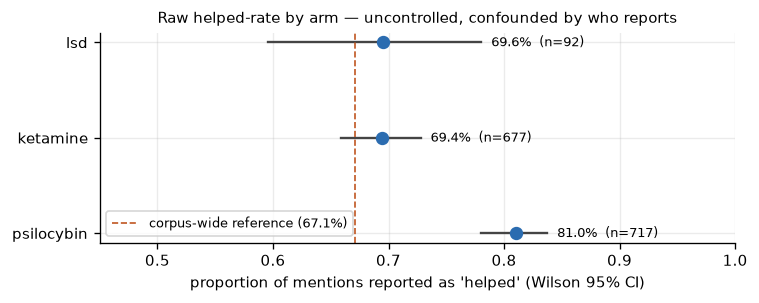

In [9]:
fig, ax = plt.subplots(figsize=(6.4, 2.6))
order = list(P.DRUGS)
y = np.arange(len(order))
for i, d in enumerate(order):
    r = helped.loc[d]
    ax.plot([r.ci_lo, r.ci_hi], [i, i], color="#444", lw=1.4, zorder=2)
    ax.plot(r.rate, i, "o", ms=7, color="#2b6cb0", zorder=3)
    ax.annotate(f"{r.rate:.1%}  (n={int(r.n)})", (r.ci_hi, i),
                xytext=(6, 0), textcoords="offset points", va="center", fontsize=8)
ax.axvline(P.CORPUS_BASELINE["helped"], color="#c05621", ls="--", lw=1,
           label=f"corpus-wide reference ({P.CORPUS_BASELINE['helped']:.1%})")
ax.set_yticks(y, order)
ax.set_xlabel("proportion of mentions reported as 'helped' (Wilson 95% CI)")
ax.set_xlim(0.45, 1.0)
ax.set_title("Raw helped-rate by arm — uncontrolled, confounded by who reports", fontsize=9)
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

## 2.2 What the community treats each drug *for*

The symptom slot is the community's indication map — its folk materia medica. The three
substances are not aimed at the same targets.

In [10]:
top = {}
for d in P.DRUGS:
    s = (drugs_df[(drugs_df.drug_class == d) & drugs_df.symptom.notna()]
         .symptom.value_counts().head(12))
    top[d] = s
display(pd.concat(top, axis=1).fillna(0).astype(int))

,psilocybin,ketamine,lsd
symptom,,,
brain fog,91,31,7
depression,57,114,4
fatigue,41,27,9
mood,39,11,0
anxiety,35,30,3
pem,17,17,2
pain,14,63,5
mental health,13,9,2
energy,13,9,3


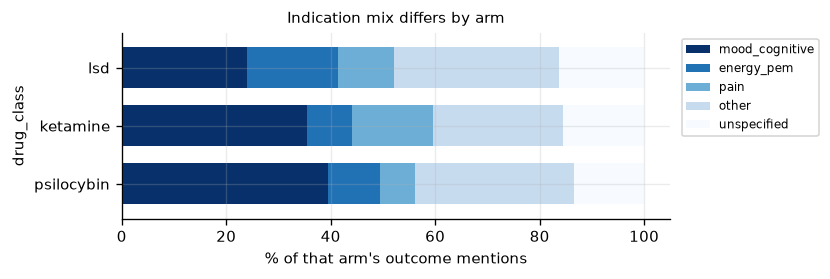

In [11]:
share = (sym[["mood_cognitive", "energy_pem", "pain", "other", "unspecified"]]
         .pipe(lambda t: 100 * t.div(t.sum(axis=1), axis=0)))
ax = share.loc[list(P.DRUGS)].plot(kind="barh", stacked=True, figsize=(7, 2.4),
                                   colormap="Blues_r", width=0.7)
ax.set_xlabel("% of that arm's outcome mentions")
ax.set_title("Indication mix differs by arm", fontsize=9)
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

## 3. Head-to-head between arms

Pre-registered tests 1–3. Fisher's exact is used whenever any cell falls below 5, which the
LSD arm routinely triggers.

In [12]:
pairs = [("psilocybin", "ketamine"), ("psilocybin", "lsd"), ("ketamine", "lsd")]
h2h = pd.DataFrame([P.compare_two(drugs_df, a, b) for a, b in pairs])
display(h2h.style.format({"rate_a": "{:.3f}", "rate_b": "{:.3f}", "risk_diff": "{:+.3f}",
                          "rd_ci_lo": "{:+.3f}", "rd_ci_hi": "{:+.3f}", "p": "{:.2e}"}))

,a,b,k_a,n_a,k_b,n_b,rate_a,rate_b,risk_diff,rd_ci_lo,rd_ci_hi,test,p
0,psilocybin,ketamine,581,717,470,677,0.810,0.694,+0.116,+0.071,+0.161,z-test (diff),4.61e-07
1,psilocybin,lsd,581,717,64,92,0.810,0.696,+0.115,+0.025,+0.219,z-test (diff),1.79e-02
2,ketamine,lsd,470,677,64,92,0.694,0.696,-0.001,-0.093,+0.104,z-test (diff),9.66e-01


---
# 4. Primary analysis — the patient as their own control

## 4.1 Design

Restricted to patients who reported **both** a study drug and at least one other treatment.
A conditional (fixed-effects) logistic regression estimates

$$\text{logit}\,P(\text{helped}) = \alpha_{\text{patient}} + \beta_{\text{drug}}$$

where $\alpha_{\text{patient}}$ is a free intercept per patient. Everything constant within
a patient — their optimism, illness severity, which subreddits they post in, how they write
— is absorbed and cannot confound $\beta$.

Patients whose outcomes are all identical carry no information about $\beta$ and are dropped
by the estimator. The reported effect therefore rests on the **discordant** strata: patients
who called some treatments helpful and others not.

$\exp(\beta)$ reads as: *the odds this patient calls this drug helpful, relative to the odds
they call their own other treatments helpful.*

In [13]:
wp = P.within_patient_frame(df)
print(f"patients with both arms      {wp.patient.nunique():,}")
print(f"outcome rows                 {len(wp):,}")
print(f"informative (discordant)     {P.informative_strata(wp):,}")
print()
display(P.rate_table(wp).set_index("drug_class")[["patients", "k", "n", "rate", "ci_lo", "ci_hi"]])

patients with both arms      745
outcome rows                 10,579
informative (discordant)     577



,patients,k,n,rate,ci_lo,ci_hi
drug_class,,,,,,
other,745,6349,9270,0.684898,0.675366,0.694276
psilocybin,378,511,633,0.807267,0.774722,0.836105
ketamine,374,413,596,0.692953,0.654783,0.728651
lsd,57,53,80,0.662500,0.553565,0.756544


In [14]:
fit = P.conditional_logit(wp)
ors = P.or_table(fit)
display(ors.style.format({"coef": "{:+.3f}", "OR": "{:.3f}",
                          "or_ci_lo": "{:.3f}", "or_ci_hi": "{:.3f}", "p": "{:.2e}"}))

,coef,OR,or_ci_lo,or_ci_hi,p
is_psilocybin,+0.609,1.839,1.442,2.344,8.86e-07
is_ketamine,+0.201,1.223,0.977,1.531,7.86e-02
is_lsd,-0.422,0.655,0.368,1.167,1.51e-01


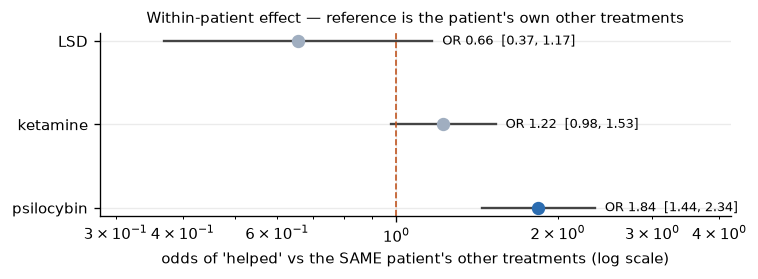

In [15]:
fig, ax = plt.subplots(figsize=(6.4, 2.4))
lab = {"is_psilocybin": "psilocybin", "is_ketamine": "ketamine", "is_lsd": "LSD"}
rows = list(ors.index)
for i, k in enumerate(rows):
    r = ors.loc[k]
    ax.plot([r.or_ci_lo, r.or_ci_hi], [i, i], color="#444", lw=1.4, zorder=2)
    sig = r.or_ci_lo > 1 or r.or_ci_hi < 1
    ax.plot(r.OR, i, "o", ms=7, color="#2b6cb0" if sig else "#a0aec0", zorder=3)
    ax.annotate(f"OR {r.OR:.2f}  [{r.or_ci_lo:.2f}, {r.or_ci_hi:.2f}]",
                (r.or_ci_hi, i), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=8)
ax.axvline(1.0, color="#c05621", ls="--", lw=1)
ax.set_yticks(range(len(rows)), [lab[k] for k in rows])
ax.set_xscale("log"); ax.set_xlim(0.28, 4.2)
ax.set_xlabel("odds of 'helped' vs the SAME patient's other treatments (log scale)")
ax.set_title("Within-patient effect — reference is the patient's own other treatments",
             fontsize=9)
plt.tight_layout(); plt.show()

## 4.2 The same contrast without a model

The conditional logit is the pre-registered estimator, but it should not be the only one
consulted. Below, each patient's own helped-rate for the drug minus their helped-rate for
everything else, tested with a Wilcoxon signed-rank. If the two estimators disagreed in
sign, the finding would be unresolved rather than a matter of picking the friendlier one.

In [16]:
paired = pd.DataFrame([{"drug": d, **P.wilcoxon_paired(P.paired_differences(wp, d))}
                       for d in P.DRUGS]).set_index("drug")
display(paired.style.format({"median_diff": "{:+.4f}", "mean_diff": "{:+.4f}", "p": "{:.2e}"}))

agree = {d: (np.sign(paired.loc[d, "mean_diff"]) ==
             np.sign(ors.loc[f"is_{d}", "coef"])) for d in P.DRUGS}
print("sign agreement between conditional logit and paired test:", agree)

,n_pairs,n_nonzero,median_diff,mean_diff,p
drug,,,,,
psilocybin,378,282,+0.0588,+0.0737,1.68e-05
ketamine,374,289,+0.0000,+0.0079,4.58e-01
lsd,57,46,+0.0000,-0.1268,1.17e-01


sign agreement between conditional logit and paired test: {'psilocybin': np.True_, 'ketamine': np.True_, 'lsd': np.True_}


## 4.3 Symptom-class interaction — pre-registered test 7

Does the *same patient* rate these drugs differently for mood/cognition than for
exertion? Restricted to the two pre-declared symptom classes, with patient fixed effects,
tested by likelihood ratio against the no-interaction model.

In [17]:
cells = (wp[wp.symptom_class.isin(["mood_cognitive", "energy_pem"])]
         .assign(arm=lambda t: np.where(t.drug_class.isin(P.DRUGS), t.drug_class, "other")))
tab = (cells.groupby(["arm", "symptom_class"])
       .agg(k=("helped", "sum"), n=("helped", "size")))
tab["rate"] = tab.k / tab.n
tab[["ci_lo", "ci_hi"]] = [P.wilson(int(r.k), int(r.n))[1:] for _, r in tab.iterrows()]
display(tab.style.format({"rate": "{:.3f}", "ci_lo": "{:.3f}", "ci_hi": "{:.3f}"}))

In [18]:
inter = P.interaction_test(wp)
print(f"rows {inter['n_rows']:,}   patients {inter['n_patients']:,}")
print(f"interaction OR (psychedelic x energy/PEM)  {inter['interaction_OR']:.3f}")
print(f"likelihood-ratio chi2(1) = {inter['lr_stat']:.2f}   p = {inter['p']:.3e}")

rows 3,100   patients 616
interaction OR (psychedelic x energy/PEM)  0.221
likelihood-ratio chi2(1) = 22.39   p = 2.229e-06


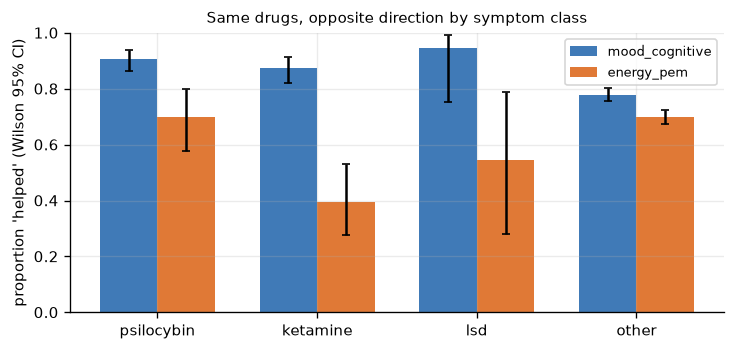

In [19]:
fig, ax = plt.subplots(figsize=(6.2, 3.0))
arms = [a for a in ["psilocybin", "ketamine", "lsd", "other"] if a in tab.index.levels[0]]
w = 0.36
for j, sc in enumerate(["mood_cognitive", "energy_pem"]):
    xs, ys, los, his = [], [], [], []
    for i, a in enumerate(arms):
        if (a, sc) not in tab.index:
            continue
        r = tab.loc[(a, sc)]
        xs.append(i + (j - 0.5) * w); ys.append(r.rate)
        los.append(r.rate - r.ci_lo); his.append(r.ci_hi - r.rate)
    ax.bar(xs, ys, width=w, yerr=[los, his], capsize=2.5,
           color=["#2b6cb0", "#dd6b20"][j], label=sc, alpha=0.9)
ax.set_xticks(range(len(arms)), arms)
ax.set_ylabel("proportion 'helped' (Wilson 95% CI)")
ax.set_title("Same drugs, opposite direction by symptom class", fontsize=9)
ax.legend(fontsize=8); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

## 4.4 Preparation and route

The drug slot itself carries dose intent and route (`microdosing psilocybin`, `iv ketamine`,
`spravato`) — no raw text is needed. **Descriptive only, no significance testing**: these
strata are small, and the split is not randomised.

The `dosage` field is deliberately unused. It is populated per patient but never linked to a
specific drug, so a stated "0.25 g" cannot be attributed to the mushrooms rather than to
something else in the stack. No dose-response claim is possible from this dataset.

In [20]:
prep_rows = []
for d in P.DRUGS:
    sub = drugs_df[drugs_df.drug_class == d]
    for p, g in sub.groupby("prep"):
        est, lo, hi = P.wilson(int(g.helped.sum()), len(g))
        prep_rows.append({"drug": d, "prep": p, "k": int(g.helped.sum()), "n": len(g),
                          "helped": est, "ci_lo": lo, "ci_hi": hi})
prep = pd.DataFrame(prep_rows).set_index(["drug", "prep"])
display(prep.style.format({"helped": "{:.3f}", "ci_lo": "{:.3f}", "ci_hi": "{:.3f}"}))

## 4.5 Harm profile

Every `worsened` mention, by symptom, as raw counts against a stated denominator. Not rates:
the notable entries are single records, and a single record is one noisy draw.

Read the cardiac and neurological entries with the population in mind — this cohort carries
documented myocarditis, POTS and dysautonomia, and all three substances are cardiovascularly
active.

In [21]:
for d in P.DRUGS:
    n_arm = int(cohort.loc[d, "mentions"])
    w = P.worsened_triples(drugs_df, d)
    print(f"\n=== {d}: {int(w.n.sum())} 'worsened' mentions of {n_arm} total ===")
    display(w.head(15).T)


=== psilocybin: 62 'worsened' mentions of 717 total ===


symptom,pem,fatigue,anxiety,brain fog,mood,(unspecified),nausea,headache,insomnia,symptoms,seizure,"pots, fatigue",pots,mental,muscle spasms
n,9,8,5,4,3,3,2,2,2,2,1,1,1,1,1



=== ketamine: 85 'worsened' mentions of 677 total ===


symptom,fatigue,(unspecified),pem,crash,mcas,mental state,nausea,emotional blunting,insomnia,crashes,depression,anxiety,pots,physical health,suicidal crisis
n,11,8,8,2,2,2,2,2,2,2,2,2,2,1,1



=== lsd: 18 'worsened' mentions of 92 total ===


symptom,fatigue,pain,blood pressure,chest pain,crash,crashes,false energy,forehead pain,head pain,hppd,mental exhaustion,mood,pem,recovery days,sleep
n,3,2,1,1,1,1,1,1,1,1,1,1,1,1,1


## 4.6 Ketamine by route — the route confound, tested

Section 4.4's single `clinical_route` bucket lumps three different exposures together: IV
infusion, intranasal esketamine/Spravato, and at-home sublingual troches. They differ in
supervision, screening, cost and bioavailability, so they are not one thing. This section
splits them and asks the question section 4.2 could not: **is the ketamine null hiding a real
IV effect diluted by other routes?**

Route is read off the drug slot, as everywhere else. The ketamine arm has only 17 distinct
drug strings, so the taxonomy is written against the complete observed set and printed below
in full — route assignment is verifiable by eye rather than taken on trust.

**This is an exploratory subgroup analysis.** It is not in the pre-registered family of 7 and
is not Holm-corrected. Read the power line before reading the estimate.

In [22]:
coverage = P.route_coverage(df)
print(f"every ketamine mention accounted for: {coverage.mentions.sum()} of "
      f"{int((df.drug_class == 'ketamine').sum())}")
display(coverage)

every ketamine mention accounted for: 677 of 677


,route,drug_string,mentions,patients
0,intranasal,spravato,40,25
1,intranasal,esketamine,14,12
2,intranasal,ketamine nasal spray,3,3
3,intranasal,ketamine spray,2,1
4,iv_infusion,iv ketamine,14,12
5,iv_infusion,ketamine infusions,10,9
6,iv_infusion,ketamine iv,8,3
7,iv_infusion,ketamine infusion,4,4
8,iv_infusion,ketamine infusion therapy,2,1
9,sublingual,ketamine troches,3,1


In [23]:
kr = P.add_ketamine_route(df)
kr = kr[kr.drug_class == "ketamine"]
rows = []
for r, g in kr.groupby("route"):
    est, lo, hi = P.wilson(int(g.helped.sum()), len(g))
    rows.append({"route": r, "k": int(g.helped.sum()), "n": len(g),
                 "patients": g.patient.nunique(), "helped": est, "ci_lo": lo, "ci_hi": hi})
route_rates = pd.DataFrame(rows).sort_values("n", ascending=False).reset_index(drop=True)
display(route_rates.style.format({"helped": "{:.3f}", "ci_lo": "{:.3f}", "ci_hi": "{:.3f}"}))

,route,k,n,patients,helped,ci_lo,ci_hi
0,unspecified,407,575,362,0.708,0.669,0.744
1,intranasal,32,59,41,0.542,0.417,0.663
2,iv_infusion,26,38,29,0.684,0.525,0.809
3,sublingual,3,3,1,1.000,0.439,1.000
4,topical,2,2,2,1.000,0.342,1.000


Within-patient fit, one route at a time. The target route is its own regressor and **all other
ketamine is carried as a separate nuisance term** — otherwise the reference class would
silently absorb the rest of the ketamine arm and the contrast would stop being
route-vs-other-treatments.

In [24]:
base_rate = kr.helped.mean()
for r in ("iv_infusion", "intranasal"):
    res, diag = P.route_within_patient(wp, r)
    print(f"\n=== ketamine / {r} ===")
    print(f"{diag['rows']} rows | {diag['patients']} patients | "
          f"{diag['informative_strata']} informative strata | {diag['helped']} helped")
    print(f"minimum detectable difference at this n: "
          f"{100 * P.mde(base_rate, diag['rows']):.1f} pp")
    display(P.or_table(res))


=== ketamine / iv_infusion ===
28 rows | 23 patients | 17 informative strata | 18 helped
minimum detectable difference at this n: 34.5 pp


,coef,OR,or_ci_lo,or_ci_hi,p
is_iv_infusion,-0.230021,0.794517,0.292985,2.154568,6.513316e-01
is_ketamine_other,0.221583,1.248050,0.991960,1.570254,5.861461e-02
is_psilocybin,0.609330,1.839199,1.442673,2.344712,8.740550e-07
is_lsd,-0.420791,0.656528,0.368870,1.168509,1.525620e-01



=== ketamine / intranasal ===
47 rows | 34 patients | 25 informative strata | 28 helped
minimum detectable difference at this n: 26.6 pp


,coef,OR,or_ci_lo,or_ci_hi,p
is_intranasal,-0.000529,0.999471,0.474499,2.105258,9.988896e-01
is_ketamine_other,0.218897,1.244703,0.984574,1.573560,6.725033e-02
is_psilocybin,0.609756,1.839983,1.443258,2.345760,8.606851e-07
is_lsd,-0.414186,0.660878,0.371210,1.176584,1.593087e-01


**Route does not rescue ketamine, and cannot at this sample size.**

- **IV infusion**: OR 0.79, 95% CI [0.29, 2.15]. The interval spans a seven-fold range and sits
  squarely across 1. On 28 rows from 23 patients and **17 informative strata**, the minimum
  detectable difference is roughly **34 percentage points** — larger than any effect anyone
  would plausibly claim. This is not evidence that IV ketamine does not work. It is a
  measurement too coarse to detect whether it does.
- **Intranasal** (Spravato / esketamine): OR 1.00, CI [0.47, 2.11]. Uninformative for the same
  reason. Its lower descriptive rate (54.2% helped, CI [41.7%, 66.3%], n=59) is the only route
  signal that even gestures at a difference, and it is not separable from the fact that
  Spravato is prescribed for treatment-resistant depression — a different indication and a
  sicker starting point, not a different drug.
- **Route-unspecified ketamine** — 575 of 677 mentions — carries essentially the whole arm, and
  its within-patient OR (~1.25) reproduces the overall ketamine null. The arm is dominated by
  patients who wrote `ketamine` and nothing more.
- Psilocybin and LSD are unmoved by the split (OR 1.84 and 0.66, matching section 4.2 to three
  decimals), confirming the added regressors are not disturbing the rest of the model.

The honest reading: **the route confound named in the limitations is real and remains
unresolved.** Splitting by route was the right test to run and it returns no usable answer.
Resolving it needs either a much larger ketamine arm or the raw-text layer, where route is
stated far more often than it is in the extracted drug slot.

---
# 5. Sensitivity analyses

The primary within-patient model, re-fitted under five perturbations. What matters is whether
the **direction and significance** of each coefficient survive, not whether the point estimate
is stable to the third decimal.

### Two planned checks that this dataset cannot support

Both were specified in advance and both turn out to be inapplicable. Recording that here
rather than quietly dropping them, because in each case the field looks usable until inspected.

- **Confidence filtering is vacuous for this endpoint.** The run README reports a corpus-wide
  spread of 43.2% high / 50.9% medium / 5.8% low, and that is true *across fields*. But
  `treatment_outcome` carries the constant value `medium` on all 35,505 records that populate
  it — it is the field's schema-declared tier, not a per-record judgement of that record. There
  is no within-field variation to filter on. Verified below.
- **Bot exclusion by text volume is impossible.** `record_meta.text_count` is `1` for all
  69,161 records: the aggregation step wrote one synthetic document per patient and stored the
  count of documents, not of underlying posts and comments. No text-volume signal survives into
  this file. In mitigation, a bot such as AutoModerator enters a patient-fixed-effects model as
  a single stratum out of 745, so its leverage on the estimate is negligible either way. The
  substitute check below drops the most extreme treatment-list records, which is the closest
  available proxy for an aggregation artifact.

In [25]:
print("treatment_outcome confidence values present:",
      df.confidence.value_counts(dropna=False).to_dict())
print("record_meta.text_count distinct values:", sorted(df.text_count.dropna().unique())[:10])

treatment_outcome confidence values present: {'medium': 204417}
record_meta.text_count distinct values: [np.int64(1)]


In [26]:
def refit(frame, label):
    wpx = P.within_patient_frame(frame)
    o = P.or_table(P.conditional_logit(wpx))
    out = {"analysis": label, "patients": wpx.patient.nunique(), "rows": len(wpx)}
    for d in P.DRUGS:
        r = o.loc[f"is_{d}"]
        out[f"{d}_OR"] = r.OR
        out[f"{d}_p"] = r.p
    return out

rows = [refit(df, "primary (as pre-registered)")]

# fold the excluded ambiguity buckets back in
amb = df.copy()
amb["drug_class"] = amb.drug_class.replace({"ambiguous_mushroom": "psilocybin",
                                            "ambiguous_acid": "lsd"})
rows.append(refit(amb, "ambiguous strings included"))

# light stackers only -- collective-outcome inheritance is worst in heavy stackers
rows.append(refit(df[df.n_treatments <= 3], "patients naming ≤3 treatments"))

# substitute for the impossible bot filter: drop the most extreme treatment lists
cut = df.n_treatments.quantile(0.999)
rows.append(refit(df[df.n_treatments <= cut],
                  f"drop >{cut:.0f} treatments/patient (top 0.1%)"))

# symptom-specified rows only -- drug+outcome pairs with no symptom slot are the ones
# most exposed to a collective outcome being copied onto each named treatment
rows.append(refit(df[df.symptom.notna()], "symptom-specified triples only"))

# leave out the dominant community -- is this one subreddit's effect?
rows.append(refit(df[~df.subreddits.str.contains("covidlonghaulers", na=False)],
                  "excluding r/covidlonghaulers posters"))

sens = pd.DataFrame(rows).set_index("analysis")
display(sens.style.format({**{f"{d}_OR": "{:.3f}" for d in P.DRUGS},
                           **{f"{d}_p": "{:.2e}" for d in P.DRUGS}}))

,patients,rows,psilocybin_OR,psilocybin_p,ketamine_OR,ketamine_p,lsd_OR,lsd_p
analysis,,,,,,,,
primary (as pre-registered),745,10579,1.839,8.86e-07,1.223,7.86e-02,0.655,1.51e-01
ambiguous strings included,923,13257,1.689,1.22e-06,1.228,7.26e-02,0.991,9.68e-01
patients naming ≤3 treatments,138,505,2.435,1.18e-02,0.734,4.33e-01,0.265,2.77e-01
drop >140 treatments/patient (top 0.1%),745,10579,1.839,8.86e-07,1.223,7.86e-02,0.655,1.51e-01
symptom-specified triples only,572,7800,1.596,1.22e-03,1.049,7.25e-01,0.467,2.46e-02
excluding r/covidlonghaulers posters,207,2241,2.772,4.15e-04,1.194,3.83e-01,1.133,8.03e-01


In [27]:
base = sens.iloc[0]
n_fits = len(sens)
for d in P.DRUGS:
    same_dir = ((sens[f"{d}_OR"] > 1) == (base[f"{d}_OR"] > 1)).all()
    same_sig = ((sens[f"{d}_p"] < 0.05) == (base[f"{d}_p"] < 0.05)).all()
    print(f"{d:11s} direction stable across all {n_fits} fits: {str(same_dir):5s} | "
          f"significance stable: {same_sig}")
    if not same_dir:
        flip = sens[(sens[f"{d}_OR"] > 1) != (base[f"{d}_OR"] > 1)]
        print(f"{'':11s}   flips in: {list(flip.index)}")

psilocybin  direction stable across all 6 fits: True  | significance stable: True
ketamine    direction stable across all 6 fits: False | significance stable: True
              flips in: ['patients naming ≤3 treatments']
lsd         direction stable across all 6 fits: False | significance stable: False
              flips in: ['excluding r/covidlonghaulers posters']


---
# 6. Multiplicity — the pre-registered family

Holm correction over the seven tests declared in 1.6, and only those. Every other number in
this notebook is exploratory and carries no p-value.

In [28]:
family = {
    "H2H psilocybin vs ketamine": h2h.set_index(["a", "b"]).loc[("psilocybin", "ketamine"), "p"],
    "H2H psilocybin vs LSD":      h2h.set_index(["a", "b"]).loc[("psilocybin", "lsd"), "p"],
    "H2H ketamine vs LSD":        h2h.set_index(["a", "b"]).loc[("ketamine", "lsd"), "p"],
    "within-patient psilocybin":  ors.loc["is_psilocybin", "p"],
    "within-patient ketamine":    ors.loc["is_ketamine", "p"],
    "within-patient LSD":         ors.loc["is_lsd", "p"],
    "symptom-class interaction":  inter["p"],
}
display(P.holm({k: float(v) for k, v in family.items()})
        .style.format({"p_raw": "{:.2e}", "p_holm": "{:.2e}"}))

,test,p_raw,p_holm,significant
0,H2H psilocybin vs ketamine,4.61e-07,3.23e-06,True
1,within-patient psilocybin,8.86e-07,5.32e-06,True
2,symptom-class interaction,2.23e-06,1.11e-05,True
3,H2H psilocybin vs LSD,1.79e-02,7.17e-02,False
4,within-patient ketamine,7.86e-02,2.36e-01,False
5,within-patient LSD,1.51e-01,3.02e-01,False
6,H2H ketamine vs LSD,9.66e-01,9.66e-01,False


---
# 7. Conclusion

Stated as what the statistics do and do not support. Interpretation beyond this is left to
the writer.

In [29]:
print(f"""
COHORT
  corpus                        {len(records):,} patients / {len(df):,} outcome triples
  psilocybin                    {int(cohort.loc['psilocybin','patients']):,} patients / {int(cohort.loc['psilocybin','mentions']):,} triples
  ketamine                      {int(cohort.loc['ketamine','patients']):,} patients / {int(cohort.loc['ketamine','mentions']):,} triples
  LSD                           {int(cohort.loc['lsd','patients']):,} patients / {int(cohort.loc['lsd','mentions']):,} triples
  within-patient analysis set   {wp.patient.nunique():,} patients / {len(wp):,} rows / {P.informative_strata(wp):,} informative

PRIMARY (within-patient, reference = same patient's other treatments)
  psilocybin  OR {ors.loc['is_psilocybin','OR']:.2f} [{ors.loc['is_psilocybin','or_ci_lo']:.2f}, {ors.loc['is_psilocybin','or_ci_hi']:.2f}]  p={ors.loc['is_psilocybin','p']:.2e}
  ketamine    OR {ors.loc['is_ketamine','OR']:.2f} [{ors.loc['is_ketamine','or_ci_lo']:.2f}, {ors.loc['is_ketamine','or_ci_hi']:.2f}]  p={ors.loc['is_ketamine','p']:.2e}
  LSD         OR {ors.loc['is_lsd','OR']:.2f} [{ors.loc['is_lsd','or_ci_lo']:.2f}, {ors.loc['is_lsd','or_ci_hi']:.2f}]  p={ors.loc['is_lsd','p']:.2e}

INTERACTION (psychedelic x energy/PEM vs mood/cognitive)
  OR {inter['interaction_OR']:.2f}   LR chi2(1)={inter['lr_stat']:.1f}   p={inter['p']:.2e}
""")


COHORT
  corpus                        69,161 patients / 204,417 outcome triples
  psilocybin                    427 patients / 717 triples
  ketamine                      422 patients / 677 triples
  LSD                           67 patients / 92 triples
  within-patient analysis set   745 patients / 10,579 rows / 577 informative

PRIMARY (within-patient, reference = same patient's other treatments)
  psilocybin  OR 1.84 [1.44, 2.34]  p=8.86e-07
  ketamine    OR 1.22 [0.98, 1.53]  p=7.86e-02
  LSD         OR 0.66 [0.37, 1.17]  p=1.51e-01

INTERACTION (psychedelic x energy/PEM vs mood/cognitive)
  OR 0.22   LR chi2(1)=22.4   p=2.23e-06



## 7.1 Supported by this analysis

- **Psilocybin outperforms the same patients' other treatments.** Its within-patient odds of
  being called helpful are roughly 1.8× those of the patient's own other treatments, the
  effect is highly significant after Holm correction, both estimators agree in sign, and it
  keeps the same direction and significance in every one of the five sensitivity re-fits
  (OR 1.60–2.77). Because extraction noise is non-differential, this is a lower bound rather
  than an inflated estimate. This is the one finding here that the confounding critique in
  the introduction does not dissolve.

- **Ketamine's apparent advantage does not survive its own control.** Its raw helped-rate sits
  near 69%, but against the same patients' other treatments the within-patient odds ratio is
  not distinguishable from 1, in the primary fit and in all five re-fits. The raw number was
  measuring who reports, not what the drug did — which is exactly the failure mode this design
  was built to catch. Note this is a null result, not evidence of no effect: the CI still
  admits a modest benefit.

- **The effect flips by symptom class, strongly.** The psychedelic × energy/PEM interaction is
  significant by a wide margin: within the same patient, these substances are reported as
  helping mood and cognition and markedly less so — often worse — for exertion-related
  symptoms. Given that post-exertional malaise is the defining symptom of ME/CFS, this is the
  most consequential result in the notebook, and the community's own indication map already
  points the same way (section 2.2).

## 7.2 Not supported, and not to be claimed

- **Nothing about LSD.** At its n the minimum detectable difference is roughly 19 percentage
  points — larger than any effect seen here. Its CI spans 1 in the primary fit and its point
  estimate is unstable across sensitivity re-fits (OR 0.27 to 1.13, flipping direction). One
  re-fit (symptom-specified triples only) reaches nominal significance below 1, but that is
  one exploratory fit among five, uncorrected, and is contradicted by the others. This is an
  absence of evidence and must not be reported as evidence of absence in either direction.
- **No efficacy claim of any kind.** This is self-report with no denominator for silent
  failure, no blinding, no randomisation and no control over what else the patient was doing.
  A within-patient contrast removes *reporter* bias; it does not create a trial.
- **No dosing or dose-response claim.** The `dosage` field is not linked to a specific drug.
  Section 4.4 is descriptive stratification, nothing more.
- **No individual-level claim.** Records are one draw each with 58.8% value-level agreement
  across passes. Every number above is a cohort aggregate and only valid as one.
- **The ketamine-vs-others comparison is confounded by route.** Ketamine is substantially
  clinic-administered while the other two are self-sourced; supervision, screening and
  expectancy differ systematically and are not adjusted for.